# Lab 2 Report:
## Iris Classification with Regression

### Name: Blake Willett

In [71]:
# Import neccessary packages

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import torch

from google.colab import drive
drive.mount('/content/drive') # Allows pull images and data from Google Drive
%cd /content/drive/MyDrive/PHYS417neuralNets/Lab2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1M94wx0TfIQWCoDJLSJRl84SRZ0gYt-W7/PHYS417neuralNets/Lab2


In [72]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [73]:
Image('lab2_exercise1.png', width = 1000)

## Prepare Data

In [74]:
from sklearn.datasets import load_iris

# iris dataset is available from scikit-learn package
iris = load_iris()

# Load the X (features) and y (targets) for training
# Loads as ndarray
X_train = iris['data']
y_train = iris['target']

# Load the name labels for features and targets
feature_names = iris['feature_names']
names = iris['target_names']

# Additional data processing here (e.g. standard scaling)
# Scale like in lab 1: x' = (x-mean)/stdev
def scale_data(arr):
  # Calculate mean and standard deviation of each column.
  mean = np.mean(arr, axis = 0)
  stdev = np.std(arr, axis = 0)
  # scaledData = (data-mean)/stdev
  scaled_data = np.divide(np.subtract(arr, mean), stdev)

  return scaled_data

X_train = scale_data(X_train)

# Considered excluding outliers, but was not needed based on results

In [75]:
# Print the first 10 training samples for both features and targets

print(X_train[:10, :], y_train[:10])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]
 [-0.53717756  1.93979142 -1.16971425 -1.05217993]
 [-1.50652052  0.78880759 -1.34022653 -1.18381211]
 [-1.02184904  0.78880759 -1.2833891  -1.3154443 ]
 [-1.74885626 -0.36217625 -1.34022653 -1.3154443 ]
 [-1.14301691  0.09821729 -1.2833891  -1.44707648]] [0 0 0 0 0 0 0 0 0 0]


In [76]:
# Print the dimensions of features and targets

print(X_train.shape, y_train.shape)

(150, 4) (150,)


In [77]:
# feature_names contains name for each column in X_train
# For targets, 0 -> setosa, 1 -> versicolor, 2 -> virginica

print(feature_names, names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'] ['setosa' 'versicolor' 'virginica']


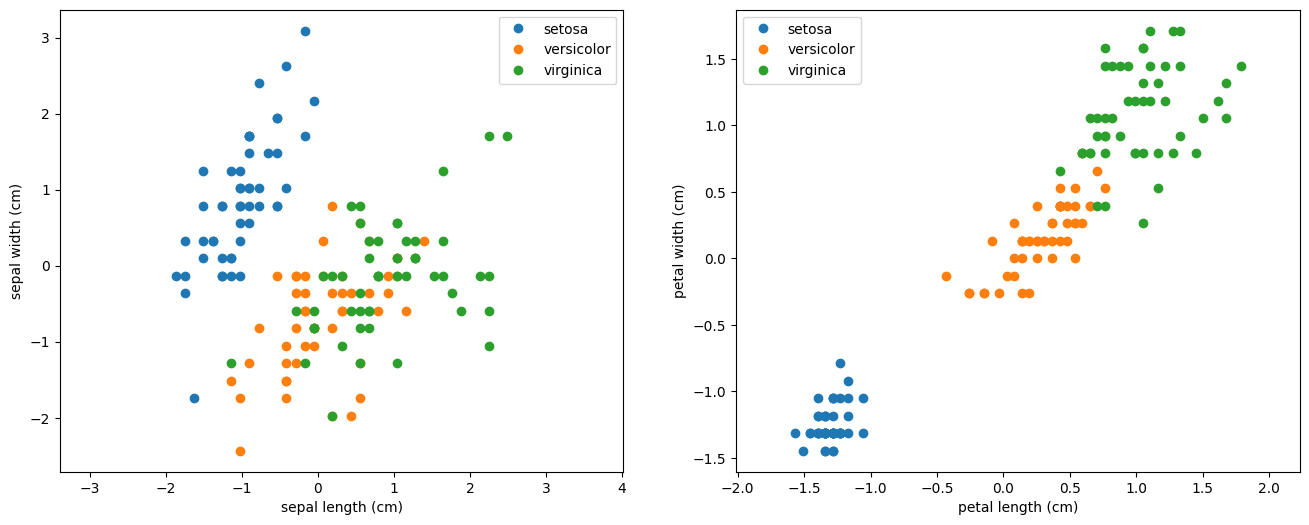

In [78]:
# We can visualize the dataset before training

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# enumerate picks up both the index (0, 1, 2) and the element ('setosa', 'versicolor', 'virginica') from "names"
# loop 1: target = 0, target_name = 'setosa'
# loop 2: target = 1, target_name = 'versicolor' etc

for target, target_name in enumerate(names):

    # Subset the rows of X_train that fall into each flower category using boolean mapping
    X_plot = X_train[y_train == target]

    # Plot the sepal length versus sepal width for the flower category
    ax1.plot(X_plot[:, 0], X_plot[:, 1], linestyle='none', marker='o', label=target_name)

# Label the plot
ax1.set_xlabel(feature_names[0])
ax1.set_ylabel(feature_names[1])
ax1.axis('equal')
ax1.legend()

# Repeat the above process but with petal length versus petal width
for target, target_name in enumerate(names):

    X_plot = X_train[y_train == target]

    ax2.plot(X_plot[:, 2], X_plot[:, 3], linestyle='none', marker='o', label=target_name)

ax2.set_xlabel(feature_names[2])
ax2.set_ylabel(feature_names[3])
ax2.axis('equal')
ax2.legend()

## Define Model

In [79]:
# Description: Linear neural model with 2 layers (i.e. 1 hidden layer)
class irisClassification(torch.nn.Module):

    # Parameters: input layer dimension, output layer dimesnion
    def __init__(self, input_dim, output_dim, hidden_dim):

        super(irisClassification, self).__init__()

        # 2 linear layers connecting input, hidden, output
        self.layer1 = torch.nn.Linear(input_dim, hidden_dim)
        self.layer2 = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x):

        # Forward propagation
        hidden = self.layer1(x)
        out = self.layer2(hidden)

        return out

## Define Hyperparameters

In [80]:
# Test different hidden layer dimensions
hidden_neurons = 8

model = irisClassification(input_dim = X_train.shape[1], output_dim = 1, hidden_dim = hidden_neurons)

learning_rate = 0.1 # Higher -> More dramatic changes in weights
# Per assignment, this has to be <50. Approach: Started with 45, check accuracy, then iterate down as able
epochs = 10

# We will use gradient descent for our optimizer and Mean Squared Error Loss function
loss_func = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

## Identify Tracked Values

In [81]:
# follow models performance over each epoch. Identify a metric and track it over epochs

# Metric = loss
trainingLoss = [] # Used an empty array and appended. Less efficient for large data, and will use an array of zeroes in future labs.

## Train Model

In [82]:
# Cast data to float PyTorch tensors
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()

for epoch in range(epochs):
    # Separate each epoch's learning
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)

    # Compute loss and append to loss list
    loss = loss_func(outputs.squeeze(), y_train)
    trainingLoss.append(loss.item())

    # Compute changes to weights
    loss.backward()

    # Update weights
    optimizer.step()

## Visualize and Evaluate Model

Text(0.5, 1.0, 'Training Loss')

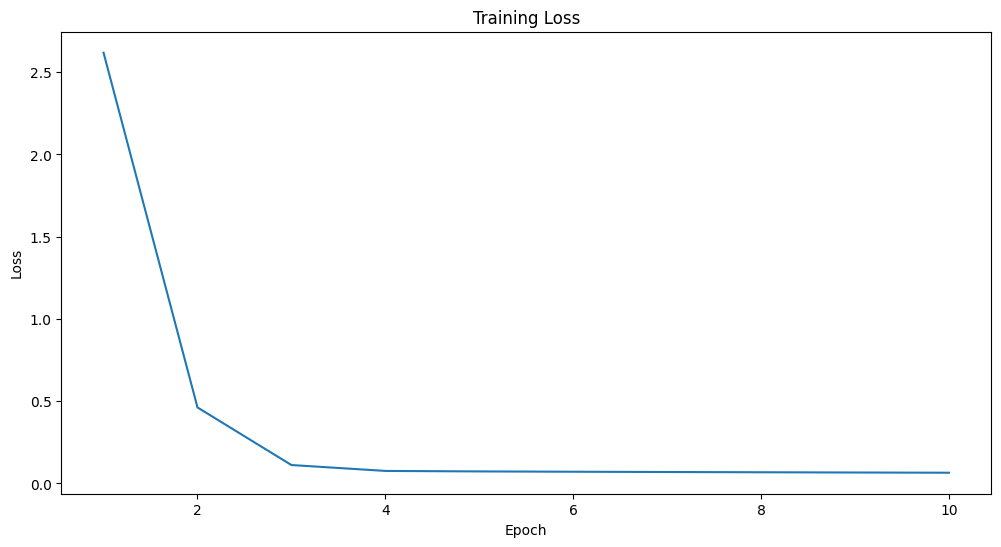

In [85]:
# Plot your training loss throughout the training
# Include proper x and y labels for the plot

plt.figure(figsize=(12, 6))

# Plot epochs v. loss throughtout training
plt.plot(np.add(range(epochs),1), trainingLoss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

In [84]:
# Confirm that your model's training accuracy is >90%

with torch.no_grad():

    # Compare your model predictions with targets (y_train) to compute the training accuracy
    # Round the model predictions to integer (e.g. 0.34 -> 0, 1.78 -> 2)
    difference = y_train - torch.round(model(X_train).squeeze())
    correct = difference[difference == 0] # If no difference between model output and target, correct

    # Training accuracy = (# of correct predictions) / (total # of training samples)
    accuracy = correct.shape[0]/y_train.shape[0]
    print(accuracy)

0.9266666666666666
